# Trabalho 2 (T2) - Previsão de carga á curto prazo do Sudeste do Brasil

<span style="color:blue">Integrante 1: João Pedro Muffato Nascimento 	         190900025(140900025?)</span>

<span style="color:green">Integrante 2: Diego Gomes Machado                      190950043</span>

<span style="color:red">Integrante 3: Vinicius Raimundo Pires                    190950026</span>

<span style="color:green">Repositório do Grupo: [Link do GitHub](https://github.com/5rdig0/PLD-and-Load-curve-analysis-of-Brazil-regions) Contendo o ambiente usado,</span> <span style="color:blue">apresentação</span> e <span style="color:green">este relatório</span>

## 1 Montagem do Dataset
<span style="color:red">
O dataset foi montado com algumas renomeações para facilitar a identificação no código além da criação de algumas colunas para facilitar a filtragem de horas, dias e meses dada a data.</span>

In [ ]:
import pandas as pd
df = pd.read_csv(r'CURVA_CARGA_2025.csv', sep=';')

df = df.rename(columns={
    "id_subsistema": "Regioes",                        # identificador da região/subsistema
    "nom_subsistema": "SUBMERCADO",                     # nome do submercado (ex: SUDESTE, SUL, etc.)
    "din_instante": "Data",                             # data/hora do registro
    "val_cargaenergiahomwmed": "Carga"                  # valor da carga de energia (variável alvo)
})

df['Data'] = pd.to_datetime(df['Data']) 
df["Mes"] = df["Data"].dt.month     # mês (1-12)
df["DIA"] = df["Data"].dt.day       # dia do mês
df["HORA"] = df["Data"].dt.hour     # hora do dia (0-23)   
df


,Regioes,SUBMERCADO,Data,Carga,Mes,DIA,HORA
0,N,NORTE,2025-01-01 00:00:00,7097.751,1,1,0
1,NE,NORDESTE,2025-01-01 00:00:00,12251.182,1,1,0
2,S,SUL,2025-01-01 00:00:00,10554.603,1,1,0
3,SE,SUDESTE,2025-01-01 00:00:00,35374.033,1,1,0
4,N,NORTE,2025-01-01 01:00:00,7053.337,1,1,1
...,...,...,...,...,...,...,...
35035,SE,SUDESTE,2025-12-31 22:00:00,44527.728,12,31,22
35036,N,NORTE,2025-12-31 23:00:00,7739.273,12,31,23
35037,NE,NORDESTE,2025-12-31 23:00:00,13066.976,12,31,23
35038,S,SUL,2025-12-31 23:00:00,11458.166,12,31,23


## 2 Perfil de Carga Anual (2025)
<span style="color:blue">
Aqui plotamos o perfil de carga do dataset completo do dataset de todos as regiões do país no mesmo gráfico, para análise da diferença de consumo de cada região.</span>

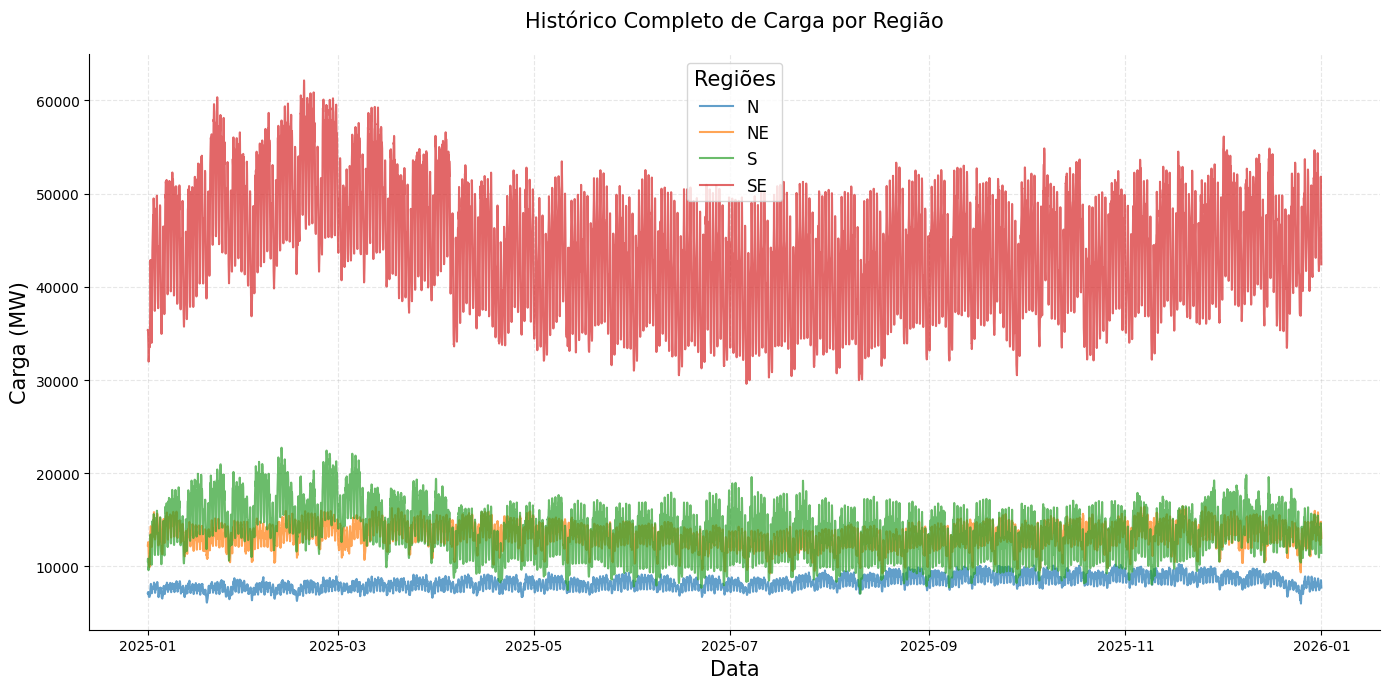

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# IMPORTANTE: Ordena por data para garantir que a linha do gráfico siga a ordem cronológica
df = df.sort_values("Data")
plt.figure(figsize=(14, 7))
regioes_unicas = df["Regioes"].unique()

for regiao in regioes_unicas:
    # Agora filtramos direto do DataFrame original 'df'
    dados_regiao = df[df["Regioes"] == regiao]
    plt.plot(dados_regiao["Data"],       # Eixo X agora usa a data completa
             dados_regiao["Carga"],    # Eixo Y usa a carga em KW
             linewidth=1.5,               # Ajustado para ficar mais sutil com muitos dados
             alpha=0.7,                   # Leve transparência para caso as curvas se sobreponham
             label=regiao.strip())

plt.title("Histórico Completo de Carga por Região", fontsize=15, pad=20)
plt.xlabel("Data", fontsize=15)
plt.ylabel("Carga (MW)", fontsize=15)
plt.legend(title="Regiões", fontsize=12, title_fontsize=15)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

## 3 Análise estátistica da carga da região Sudeste
<span style="color:green">
Aqui plotamos os dados básicos da curva de carga para evidenciar a simetria e o potêncial da curva, visando a regressão.</span>

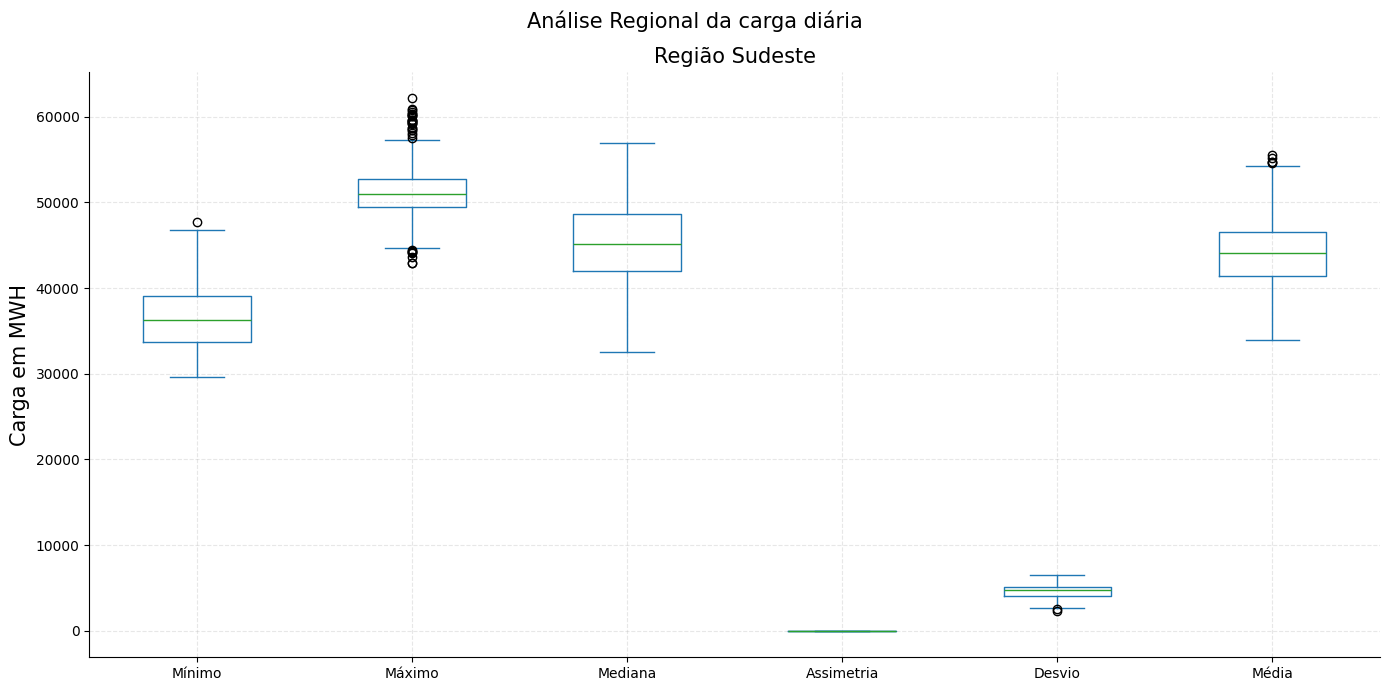

In [ ]:
#Agrupando em cada região, todos os dias de mesmo número de meses diferentes
estatistica_dia = df[["DIA", "Mes", "Regioes", "Carga"]].groupby(["Mes", "DIA", "Regioes"])

#Estatisticas de interesse
estatistica_dia_carga= estatistica_dia.agg({
  "Carga": ["min", "max", "median", "skew", "std", "mean"
            ]
})["Carga"]

estatistica_dia_carga = estatistica_dia_carga.rename(columns={
  "max":"Máximo","min":"Mínimo","std":"Desvio","mean":"Média","median":"Mediana", "skew":"Assimetria"})

fig, ax = plt.subplots(figsize=(14, 7))
estatistica_dia_carga.loc[:, :, 'SE'].plot.box(ax=ax)

# 3. Customizações do gráfico
ax.set_ylabel("Carga em MWH", fontsize=15)
ax.set_title("Região Sudeste", fontsize=15)
fig.suptitle("Análise Regional da carga diária", fontsize=15)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

## 4 Perfil de uma semana típica da carga do Sudeste
<span style="color:blue">
Aqui plotamos a curva de uma semana típica, que será o principal ponto de previsão deste trabalho.
O gráfico evidência a mudança no perfil de carga de um dia para outro, mostrando o decaimento na carga média nos fins de semana.</span>

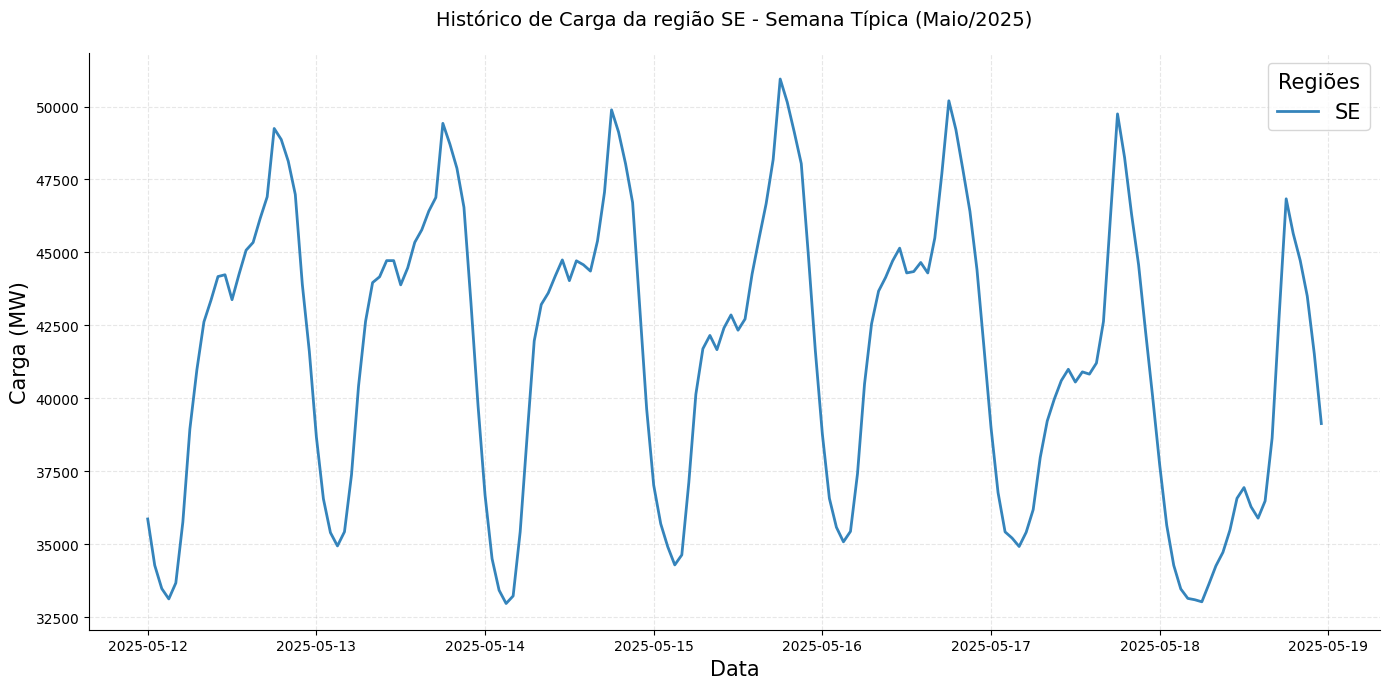

In [ ]:
# IMPORTANTE: Ordena por data para garantir que a linha do gráfico siga a ordem cronológica
df = df.sort_values("Data")

# --- FILTRO: Selecionando uma semana típica de 2025 ---
# Escolhida a semana de 12/05/2025 (Segunda) a 18/05/2025 (Domingo)
data_inicio = '2025-05-12 00:00:00'
data_fim = '2025-05-18 23:59:59'

df_semana = df[(df['Data'] >= data_inicio) & (df['Data'] <= data_fim)]

plt.figure(figsize=(14, 7))
dados_regiao = df_semana[df_semana["Regioes"] == "SE"]

plt.plot(dados_regiao["Data"],       # Eixo X com os dias e horas da semana
        dados_regiao["Carga"],    # Eixo Y usa a carga em KW
        linewidth=2,                 # Aumentado um pouco a espessura já que há menos pontos
        alpha=0.9,                   
        label=regiao.strip())

plt.title("Histórico de Carga da região SE - Semana Típica (Maio/2025)", fontsize=14, pad=20)
plt.xlabel("Data", fontsize=15)
plt.ylabel("Carga (MW)", fontsize=15)
plt.legend(title="Regiões", fontsize=15, title_fontsize=15)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

## 5 Implementação do modelo Ridge após Lasso 
<span style="color:red">
Ridge após Lasso implementado com validação cruzada.
Há um gráfico das variáveis sendo usadas e a importância delas.</span>

In [ ]:
import numpy as np                     
import pandas as pd                     
import matplotlib.pyplot as plt          
from sklearn.pipeline import Pipeline    
from sklearn.preprocessing import StandardScaler 
from sklearn.linear_model import Ridge, Lasso 
from sklearn.feature_selection import SelectFromModel 
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    root_mean_squared_error,      
    mean_absolute_error,          
    r2_score,                          
)

def RL_predict(df, submarket, horizon, lag, seed):
    np.random.seed(seed)
    df_se = df[df['SUBMERCADO'] == submarket].copy()
    df_se = df_se.drop_duplicates(
        subset=['Data', 'HORA']              # remove linhas duplicadas pra mesma data+hora
    ).sort_values(
        by=['Data', 'HORA']                  # ordena cronologicamente (essencial antes de qualquer lag/rolling)
    )
    df_se["Dia_semana"] = df_se["Data"].dt.dayofweek           # dia da semana (0=segunda ... 6=domingo)
    df_se["Semana"] = df_se["Data"].dt.isocalendar().week.astype(int)  # número da semana no ano (ISO)
    df_se["Trimestre"] = df_se["Data"].dt.quarter 
    df_se = df_se.sort_values("Data").reset_index(drop=True)

    # Confirma que não há nenhuma linha fora de ordem cronológica
    assert df_se["Data"].is_monotonic_increasing, "Data fora de ordem!"

    # Confere se o intervalo entre registros é sempre 1h (sem gaps na série)
    print(df_se["Data"].diff().value_counts())  # já confirmamos: 1h constante

    # ===================================================
    # FEATURE ENGINEERING (lags, médias móveis, etc.)
    # ===================================================

    # --- Lags: valor da Carga em horas anteriores específicas ---
    lags = [1, 2, 3, 6, 12, 24, 48, 72, 168, 336]  # 1h, 2h... até 336h (2 semanas)
    for lag in lags:
        df_se[f"lag_{lag}"] = df_se["Carga"].shift(lag)

    # --- Médias móveis: média da Carga nas últimas N horas ---
    # shift(1) garante que a hora atual NÃO entra na própria média (evita vazamento)
    for janela in [3, 6, 12, 24, 168, 720]:  # 3h, 6h... até 720h (30 dias)
        df_se[f"media_{janela}"] = df_se["Carga"].shift(1).rolling(janela).mean()

    # --- Desvio padrão, máximo e mínimo móveis (janelas de 24h e 168h/1 semana) ---
    # Também usam shift(1) pra só olhar pro passado
    for janela in [24, 168]:
        df_se[f"std_{janela}"] = df_se["Carga"].shift(1).rolling(janela).std()
        df_se[f"max_{janela}"] = df_se["Carga"].shift(1).rolling(janela).max()
        df_se[f"min_{janela}"] = df_se["Carga"].shift(1).rolling(janela).min()

    # --- Transformações cíclicas (seno/cosseno) ---
    # Transformam variáveis "circulares" (hora 23 é próxima da hora 0, por exemplo)
    # em pares contínuos que o modelo entende como proximidade real
    df_se["hora_sin"] = np.sin(2*np.pi*df_se["HORA"]/24)
    df_se["hora_cos"] = np.cos(2*np.pi*df_se["HORA"]/24)
    df_se["mes_sin"] = np.sin(2*np.pi*df_se["Mes"]/12)
    df_se["mes_cos"] = np.cos(2*np.pi*df_se["Mes"]/12)
    df_se["dia_sem_sin"] = np.sin(2*np.pi*df_se["Dia_semana"]/7)
    df_se["dia_sem_cos"] = np.cos(2*np.pi*df_se["Dia_semana"]/7)

    # Remove linhas com NaN (geradas pelos lags/rolling no início da série,
    # que não têm histórico suficiente pra calcular)
    df_model = df_se.dropna().copy()

    # ===================================================
    # DEFINIR TARGET E FEATURES
    # ===================================================

    # Lista de features = todas as colunas, exceto identificadores e a própria Carga
    features = [c for c in df_model.columns if c not in [
        "Carga", "Data", "SUBMERCADO", "Regioes"
    ]]

    # Target: Carga da PRÓXIMA semana (shift(-168)
    df_model["Target"] = df_model["Carga"].shift(-168)
    df_model = df_model.dropna()

    X = df_model[features]
    y = df_model["Target"]

    # ===================================================
    # SPLIT FINAL: TREINO (FULL) x TESTE (HOLDOUT)
    # ===================================================

    n = len(X)
    corte_teste = int(n * 0.8)  # 80% treino, 20% teste (holdout)

    # Split cronológico: teste é sempre o período mais recente, nunca embaralhado
    X_train_full, X_test = X.iloc[:corte_teste], X.iloc[corte_teste:]
    y_train_full, y_test = y.iloc[:corte_teste], y.iloc[corte_teste:]

    # ===================================================
    # PIPELINE (scaler + seleção Lasso + Ridge)
    # ===================================================

    # Lasso usado só para SELECIONAR features (via SelectFromModel),
    # não para prever diretamente
    lasso_selector = SelectFromModel(
        estimator=Lasso(alpha=1, max_iter=8000, random_state=42),
        threshold="mean"  # mantém apenas features com coeficiente acima da média (reduz o total de features)
    )
    ridge_after_lasso = Pipeline([
        ("scaler", StandardScaler()),
        ("select", lasso_selector),
        ("ridge", Ridge(alpha=1, random_state=42))
    ])

    # ===================================================
    # VALIDAÇÃO CRUZADA — SÓ DENTRO DO TREINO (X_train_full)
    # ===================================================

    # TimeSeriesSplit cria folds em janela expansível, sempre com
    # treino cronologicamente anterior à validação (sem embaralhar)
    tscv = TimeSeriesSplit(n_splits=5)

    for train_idx, val_idx in tscv.split(X_train_full):
        X_train, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
        y_train, y_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]

        ridge_after_lasso.fit(X_train, y_train)          # treina só no fold de treino

    # ===================================================
    # FIT FINAL (TODO O TREINO) E TESTE NO HOLDOUT NUNCA VISTO
    # ===================================================

    # Treina com TODO o X_train_full (não só o último fold do loop acima)
    ridge_after_lasso.fit(X_train_full, y_train_full)


    # Prediz no X_test, que nunca foi usado em nenhum fit até aqui
    pred = ridge_after_lasso.predict(X_test)

    # Métricas finais de avaliação
    rmse = root_mean_squared_error(y_test, pred)   # erro em MW, penaliza mais os erros grandes
    mae = mean_absolute_error(y_test, pred)          # erro médio em MW, mais fácil de interpretar
    r2 = r2_score(y_test, pred)                       # proporção da variância explicada (0 a 1)

    # Extrai um array booleano indicando quais features sobreviveram à seleção do Lasso
    # (True = mantida, False = descartada)
    mask_selecionadas = ridge_after_lasso.named_steps["select"].get_support()

    # Aplica a máscara na lista original de features pra pegar só os nomes das mantidas
    nomes_selecionados = np.array(features)[mask_selecionadas]

    # Pega os coeficientes do Ridge, que foi treinado só com as features selecionadas pelo Lasso
    coefs = ridge_after_lasso.named_steps["ridge"].coef_

    # Ordena os índices pelo valor absoluto do coeficiente, do maior pro menor
    # (isso captura tanto influência positiva quanto negativa, sem distinção de sinal)
    ordem = np.argsort(np.abs(coefs))[::-1]
    nomes_ord = nomes_selecionados[ordem]   # nomes reordenados por importância
    coefs_ord = coefs[ordem]                 # coeficientes reordenados por importância

    # --- Gráfico de barras horizontais com a importância de cada feature ---
    plt.figure(figsize=(10, max(6, len(nomes_ord) * 0.3)))  # altura cresce conforme o nº de features, pra não espremer o gráfico

    # Define a cor de cada barra: azul se o coeficiente for positivo, vermelho se negativo
    cores = ["#2E86AB" if c > 0 else "#C1272D" for c in coefs_ord]

    plt.barh(nomes_ord, coefs_ord, color=cores)   # barras horizontais (uma por feature)
    plt.axvline(0, color="black", linewidth=0.8)   # linha vertical no zero, pra separar visualmente positivo/negativo
    plt.xlabel("Coeficiente (Ridge)", fontsize=15)
    plt.title(f"Importância das Features ({len(nomes_ord)} de {len(features)} selecionadas pelo Lasso)", fontsize=15)
    plt.gca().invert_yaxis()   # inverte o eixo Y pra a feature mais importante ficar no topo
    plt.tight_layout()
    plt.show()

    label = f'Predição Livre de {horizon}h com Ridge após Lasso \nMAE: {mae:.2f} MW, R2: {r2:.4f}, RMSE: {rmse:.4f} MW'
    pred = pred[:168]
    y_test = y_test.values[:168]

    return({"result": pred,
            "test_y": y_test,
            "mae": mae,
            "r2": r2,
            "rmse": rmse,
            "label": label})

## 6 Implementação do modelo Ridge após Lasso 
<span style="color:blue">
FROLS implementado com lag de 24 e número de variáveis de 13 (obtido por loop, que não está aqui mais).</span>

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sysidentpy.model_structure_selection import FROLS
from sysidentpy.basis_function import Polynomial
from sysidentpy.parameter_estimation.estimators import LeastSquares 

def FROLS_predict(df, submarket, horizon, lag, seed):
    np.random.seed(seed)
    #Filtragem da região do Brasil
    df_se = df[df['SUBMERCADO'] == submarket].copy()
    df_se = df_se.drop_duplicates(subset=['Data', 'HORA']).sort_values(by=['Data', 'HORA'])
    #Reformulando as cargas como y e x como tempo
    y = df_se['Carga'].values.reshape(-1, 1)
    X_tempo = df_se['HORA'].values.reshape(-1, 1)

    split_idx = int(len(y) * 0.8)
    #Vetores de treino e teste
    y_train = y[:split_idx]
    y_test = y[split_idx:]
    X_train = X_tempo[:split_idx]
    X_test = X_tempo[split_idx:]

    scaler_y = StandardScaler()
    scaler_x = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train)
    X_train_scaled = scaler_x.fit_transform(X_train)

    # Aplicamos (transform) a mesma escala no teste
    y_test_scaled = scaler_y.transform(y_test)
    X_test_scaled = scaler_x.transform(X_test)
    basis_function = Polynomial(degree=1)

    #Modelo FROLS usado
    modelo_narx = FROLS(
        order_selection=True,
        n_info_values=13, 
        ylag=24,          
        xlag=24,          
        info_criteria='aic',
        estimator=LeastSquares(), 
        basis_function=basis_function
    )

    modelo_narx.fit(X=X_train_scaled, y=y_train_scaled)
    y_test_janela_scaled = y_test_scaled[:horizon]
    X_test_janela_scaled = X_test_scaled[:horizon]

    #Aplicando a regressão
    previsoes_livres_scaled = modelo_narx.predict(
        X=X_test_janela_scaled, 
        y=y_test_janela_scaled, 
        steps_ahead=horizon
    )
    #"Desescalando" os valores
    previsoes_livres = scaler_y.inverse_transform(previsoes_livres_scaled)
    y_test_janela = scaler_y.inverse_transform(y_test_janela_scaled)
    
    #Métricas
    mae = mean_absolute_error(y_test_janela, previsoes_livres)
    r2= r2_score(y_test_janela, previsoes_livres)
    rmse = np.sqrt(mean_squared_error(y_test_janela, previsoes_livres))
    label = f'Predição Livre de {horizon}h com FROLS \nMAE: {mae:.2f} MW, R2: {r2:.4f}, RMSE: {rmse:.4f} MW'


    return({"result": previsoes_livres,
            "test_y": y_test_janela,
            "mae": mae,
            "r2": r2,
            "rmse": rmse,
            "label": label})

## 7 Implementação do modelo SVR
<span style="color:green">
SVR implementado com lag y arbitrário e lag x trivial.</span>

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sysidentpy.basis_function import Polynomial
from sklearn.svm import SVR
from sysidentpy.general_estimators import NARX

def SVM_predict(df, submarket, horizon, lag, seed):
    np.random.seed(seed)
    #Filtragem da região do Brasil
    df_se = df[df['SUBMERCADO'] == submarket].copy()
    df_se = df_se.drop_duplicates(subset=['Data', 'HORA']).sort_values(by=['Data', 'HORA'])
    y = df_se['Carga'].values.reshape(-1, 1)
    X_tempo = df_se['HORA'].values.reshape(-1, 1)

    split_idx = int(len(y) * 0.8)

    y_train = y[:split_idx]
    y_test = y[split_idx:]
    X_train = X_tempo[:split_idx]
    X_test = X_tempo[split_idx:]

    # 1. Configurando o SVR (podemos voltar a usar um C mais forte já que tiramos o ruído)
    svr_estimator = SVR(kernel='rbf', C=10.0, gamma='scale', epsilon=0.01)
    basis_function = Polynomial(degree=1)

    # 2. Usamos o NARX, mas filtramos os lags explicitamente usando listas!
    modelo_svr_otimizado = NARX(
        base_estimator=svr_estimator,
        # Em vez de olhar as últimas 24h inteiras, olhamos apenas: 1h atrás, 2h atrás e 24h atrás
        ylag=[1, 2, 3, 4, 6, 12, 21, 22, 23, 24], 
        # Para a hora do dia, olhamos: a hora anterior e a mesma hora de ontem
        xlag=[1, 24],    
        basis_function=basis_function,
        model_type="NARMAX"
    )

    # --- SCALING DOS DADOS ---
    scaler_y = StandardScaler()
    scaler_x = StandardScaler()

    y_train_scaled = scaler_y.fit_transform(y_train)
    X_train_scaled = scaler_x.fit_transform(X_train)
    y_test_scaled = scaler_y.transform(y_test)
    X_test_scaled = scaler_x.transform(X_test)

    # 3. Treinamento (Como voltamos pro NARX, o scikit-learn exige o .ravel())
    modelo_svr_otimizado.fit(X=X_train_scaled, y=y_train_scaled.ravel())

    # 4. Preparação da Janela
    y_test_janela_scaled = y_test_scaled[:horizon]
    X_test_janela_scaled = X_test_scaled[:horizon]

    # 5. Predição Livre
    previsoes_livres_scaled = modelo_svr_otimizado.predict(
        X=X_test_janela_scaled, 
        y=y_test_janela_scaled, 
        steps_ahead=None
    )

    # 6. Reversão de escala
    previsoes_livres = scaler_y.inverse_transform(previsoes_livres_scaled)

    y_test_janela = scaler_y.inverse_transform(y_test_janela_scaled)

    mae = mean_absolute_error(y_test_janela, previsoes_livres)
    r2 = r2_score(y_test_janela, previsoes_livres)
    rmse = np.sqrt(mean_squared_error(y_test_janela, previsoes_livres))

    # Acessa o objeto SVR treinado de dentro do NARX
    svr_treinado = modelo_svr_otimizado.base_estimator

    # Extrai o intercepto (bias) do modelo
    intercepto = svr_treinado.intercept_

    print(intercepto,  np.shape(intercepto))

    label = f'Predição Livre de {horizon}h com SVR \nMAE: {mae:.2f} MW, R2: {r2:.4f}, RMSE: {rmse:.4f} MW'

    return({"result": previsoes_livres,
            "test_y": y_test_janela,
            "mae": mae,
            "r2": r2,
            "rmse": rmse,
            "label": label
            })

## 8 Implementação do modelo SVR com GA
<span style="color:green">
SVR implementado com seus hiperparâmetros e lag y e lag x selecionados pelo GA.
O GA havia sido implementado com mais gerações e indivíduos, mas estava levando 2 horas de processamento e proza de entrega nos fez decidir pela diminuição.</span>

In [108]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sysidentpy.basis_function import Polynomial
from sklearn.svm import SVR
from sysidentpy.general_estimators import NARX
import pygad
import warnings

def SVM_GA_predict(df, submarket, horizon, lag, seed):
    np.random.seed(seed)
    df_se = df[df['SUBMERCADO'] == submarket].copy()
    df_se = df_se.drop_duplicates(subset=['Data', 'HORA']).sort_values(by=['Data', 'HORA'])
    y = df_se['Carga'].values.reshape(-1, 1)
    X_tempo = df_se['HORA'].values.reshape(-1, 1)

    split_idx = int(len(y) * 0.8)

    y_train = y[:split_idx]
    y_test = y[split_idx:]
    X_train = X_tempo[:split_idx]
    X_test = X_tempo[split_idx:]

    # --- SCALING DOS DADOS ---
    scaler_y = StandardScaler()
    scaler_x = StandardScaler()

    y_train_scaled = scaler_y.fit_transform(y_train)
    X_train_scaled = scaler_x.fit_transform(X_train)
    y_test_scaled = scaler_y.transform(y_test)
    X_test_scaled = scaler_x.transform(X_test)

    lag_size1 = 3 + lag
    lag_size2 = 3 + 2*lag

    # Ignora avisos do scikit-learn/sysidentpy durante o treinamento em massa
    warnings.filterwarnings("ignore")

    # ==============================================================================
    # 1. PREPARAÇÃO DO ESPAÇO DE BUSCA (GENES)
    # ==============================================================================
    # Definimos os limites para C, gamma e epsilon
    gene_space = [
        {'low': 0.1, 'high': 50.0},      # Gene 0: C
        {'low': 0.0001, 'high': 1.0},    # Gene 1: gamma
        {'low': 0.001, 'high': 0.1}      # Gene 2: epsilon
    ]

    # Adicionamos 24 genes binários para o ylag (representando de 1h a 24h atrás)
    gene_space.extend([[0, 1]] * lag)

    # Adicionamos 24 genes binários para o xlag (representando de 1h a 24h atrás)
    gene_space.extend([[0, 1]] * lag)

    # ==============================================================================
    # 2. FUNÇÃO DE FITNESS (AVALIAÇÃO)
    # ==============================================================================
    # Variáveis globais necessárias para a função (já devem estar carregadas no seu script)
    y_test_janela_scaled = y_test_scaled[:horizon]
    X_test_janela_scaled = X_test_scaled[:horizon]
    y_test_janela = scaler_y.inverse_transform(y_test_janela_scaled)

    def fitness_function(ga_instance, solution, solution_idx):
        # 2.1. Extração dos parâmetros contínuos
        C = solution[0]
        gamma = solution[1]
        epsilon = solution[2]
        
        # 2.2. Decodificação dos arrays binários para Lags reais
        ylag_bin = solution[3:lag_size1]
        xlag_bin = solution[lag_size1:lag_size2]
        
        # Se o gene na posição 'i' for 1, usamos o lag 'i+1'
        ylag = [i+1 for i, val in enumerate(ylag_bin) if val == 1]
        xlag = [i+1 for i, val in enumerate(xlag_bin) if val == 1]
        
        # Trava de segurança: o sysidentpy precisa de pelo menos 1 lag.
        # Se o AG tentar uma solução toda zerada, forçamos o lag 1.
        if len(ylag) == 0: ylag = [1]
        if len(xlag) == 0: xlag = [1]
        
        try:
            # 2.3. Instanciação do modelo com os genes atuais
            svr_estimator = SVR(kernel='rbf', C=C, gamma=gamma, epsilon=epsilon)
            modelo_narx = NARX(
                base_estimator=svr_estimator,
                ylag=ylag,
                xlag=xlag,
                basis_function=Polynomial(degree=1),
                model_type="NARMAX"
            )
            
            # 2.4. Treinamento
            modelo_narx.fit(X=X_train_scaled, y=y_train_scaled.ravel())
            
            # 2.5. Predição Livre (168h)
            previsoes_livres_scaled = modelo_narx.predict(
                X=X_test_janela_scaled, 
                y=y_test_janela_scaled, 
                steps_ahead=None
            )
            
            # 2.6. Reversão de escala e cálculo do R2
            previsoes_livres = scaler_y.inverse_transform(previsoes_livres_scaled)
            r2 = r2_score(y_test_janela, previsoes_livres)
            
            # Penaliza severamente predições que divergem ao infinito (R2 negativo extremo)
            if np.isnan(r2) or r2 < -5.0:
                return -5.0
                
            return r2 # PyGAD tenta MAXIMIZAR o retorno, o que é perfeito para o R2

        except Exception:
            # Se ocorrer algum erro matemático com a combinação, devolvemos um R2 terrível
            return -10.0

    # ==============================================================================
    # 3. CONFIGURAÇÃO E EXECUÇÃO DO ALGORITMO GENÉTICO
    # ==============================================================================
    ga_instance = pygad.GA(
        num_generations=15,               # Quantas rodadas de evolução (aumente se demorar pouco)
        num_parents_mating=10,            # Quantos pais se reproduzem por geração
        fitness_func=fitness_function,    # Nossa função de avaliação
        sol_per_pop=20,                   # Tamanho da população (indivíduos testados por geração)
        num_genes=lag_size2,                     # C, gamma, epsilon + 24 ylags + 24 xlags
        gene_space=gene_space,
        parent_selection_type="sss",      # Seleção estocástica
        keep_elitism=2,                   # Mantém os 2 melhores modelos intactos para a próxima geração
        crossover_type="single_point",    
        mutation_type="random",
        mutation_percent_genes=10,         # Taxa de mutação (10% dos genes)
        random_seed=42
    )

    print("Iniciando a evolução do Algoritmo Genético... Isso pode levar alguns minutos.")
    ga_instance.run()



    # ==============================================================================
    # 4. RESULTADOS E MELHOR MODELO
    # ==============================================================================
    solution, solution_fitness, solution_idx = ga_instance.best_solution()

    # Decodificando a melhor solução encontrada para exibição
    best_C = solution[0]
    best_gamma = solution[1]
    best_epsilon = solution[2]
    best_ylag = [i+1 for i, val in enumerate(solution[3:lag_size1]) if val == 1]
    best_xlag = [i+1 for i, val in enumerate(solution[lag_size1:lag_size2]) if val == 1]

    print("\n=== OTIMIZAÇÃO CONCLUÍDA ===")
    print(f"Melhor R2 encontrado na semana: {solution_fitness:.4f}")
    print(f"Parâmetros do SVR: C = {best_C:.2f}, gamma = {best_gamma:.4f}, epsilon = {best_epsilon:.4f}")
    print(f"Lags Autoregressivos (ylag): {best_ylag}")
    print(f"Lags Exógenos (xlag): {best_xlag}")

    # # Plot da evolução da métrica de fitness ao longo das gerações
    # ga_instance.plot_fitness(title="Evolução do R2 ao longo das Gerações")

    # 1. Configurando o SVR (podemos voltar a usar um C mais forte já que tiramos o ruído)
    svr_estimator = SVR(kernel='rbf', C=best_C, gamma=best_gamma, epsilon=best_epsilon)
    basis_function = Polynomial(degree=1)

    # 2. Usamos o NARX, mas filtramos os lags explicitamente usando listas!
    modelo_svr_otimizado = NARX(
        base_estimator=svr_estimator,
        # Em vez de olhar as últimas 24h inteiras, olhamos apenas: 1h atrás, 2h atrás e 24h atrás
        ylag=best_ylag, 
        # Para a hora do dia, olhamos: a hora anterior e a mesma hora de ontem
        xlag=best_xlag,    
        basis_function=basis_function,
        model_type="NARMAX"
    )

    # --- SCALING DOS DADOS ---
    scaler_y = StandardScaler()
    scaler_x = StandardScaler()

    y_train_scaled = scaler_y.fit_transform(y_train)
    X_train_scaled = scaler_x.fit_transform(X_train)
    y_test_scaled = scaler_y.transform(y_test)
    X_test_scaled = scaler_x.transform(X_test)

    # 3. Treinamento (Como voltamos pro NARX, o scikit-learn exige o .ravel())
    modelo_svr_otimizado.fit(X=X_train_scaled, y=y_train_scaled.ravel())

    # 4. Preparação da Janela
    y_test_janela_scaled = y_test_scaled[:horizon]
    X_test_janela_scaled = X_test_scaled[:horizon]

    # 5. Predição Livre
    previsoes_livres_scaled = modelo_svr_otimizado.predict(
        X=X_test_janela_scaled, 
        y=y_test_janela_scaled, 
        steps_ahead=None
    )

    # 6. Reversão de escala
    previsoes_livres = scaler_y.inverse_transform(previsoes_livres_scaled)
    y_test_janela = scaler_y.inverse_transform(y_test_janela_scaled)

    mae = mean_absolute_error(y_test_janela, previsoes_livres)
    r2 = r2_score(y_test_janela, previsoes_livres)
    rmse = np.sqrt(mean_squared_error(y_test_janela, previsoes_livres))
    label = f'Predição Livre de {horizon}h com SVR e GA \nMAE: {mae:.2f} MW, R2: {r2:.4f}, RMSE: {rmse:.4f} MW'

    return({"result": previsoes_livres,
            "test_y": y_test_janela,
            "mae": mae,
            "r2": r2,
            "rmse": rmse,
            "label": label
            })

## 9 Aplicação padronizada dos modelos
<span style="color:green">
Aqui definimos o horizonte de predição, lag, submercado e a seed usada em todos algorítmos.
Há também a definição de uma função para plotagem, garantindo os plots com mesmo design.</span>

In [109]:
import matplotlib.pyplot as plt

submarket = "SUDESTE"
horizon = 168
lag = 24
seed = 42
np.random.seed(seed)

def plot_prediction(prediction):
    plt.figure(figsize=(14, 7))
    plt.plot(prediction["test_y"], label='Carga Real')
    plt.plot(prediction["result"], label='Previsão', linestyle='--')
    plt.title(prediction["label"], fontsize=15)
    plt.legend()
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.show()

### Resultados do Ridge após Lasso


Data
0 days 01:00:00    8759
Name: count, dtype: int64


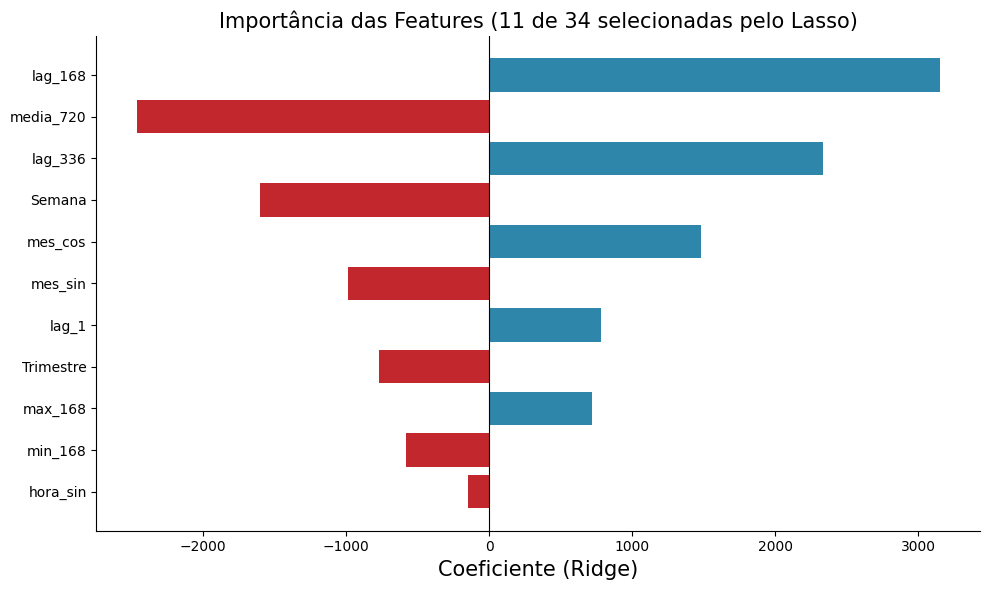

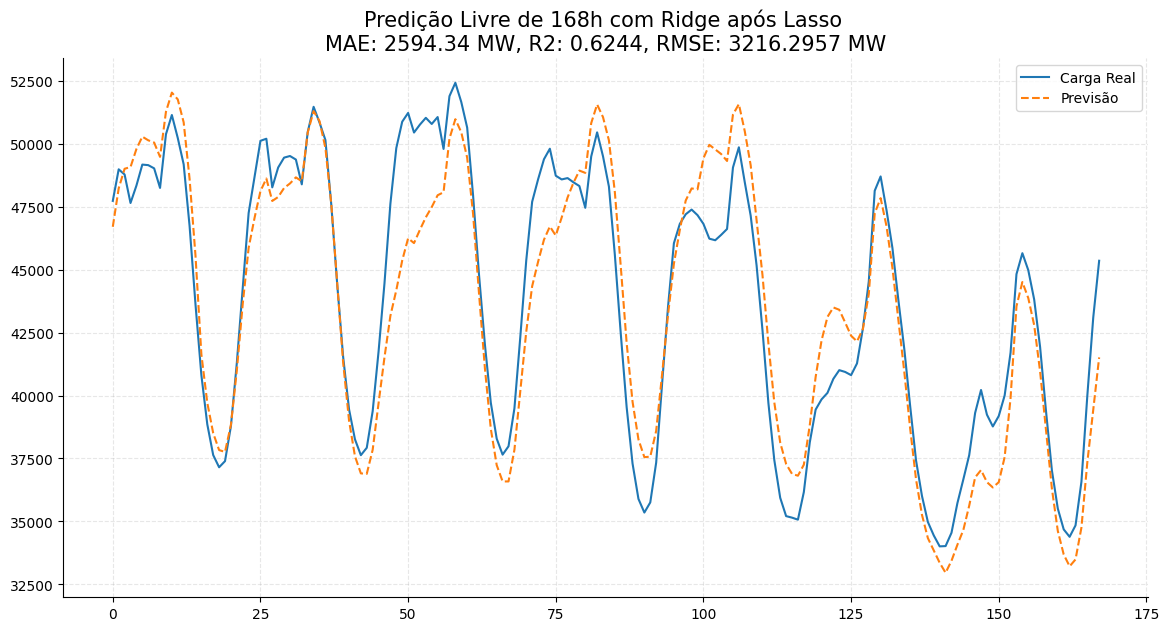

In [110]:
prediction = RL_predict(df, submarket, horizon, lag, seed)
plot_prediction(prediction)

### Resultados do FROLS

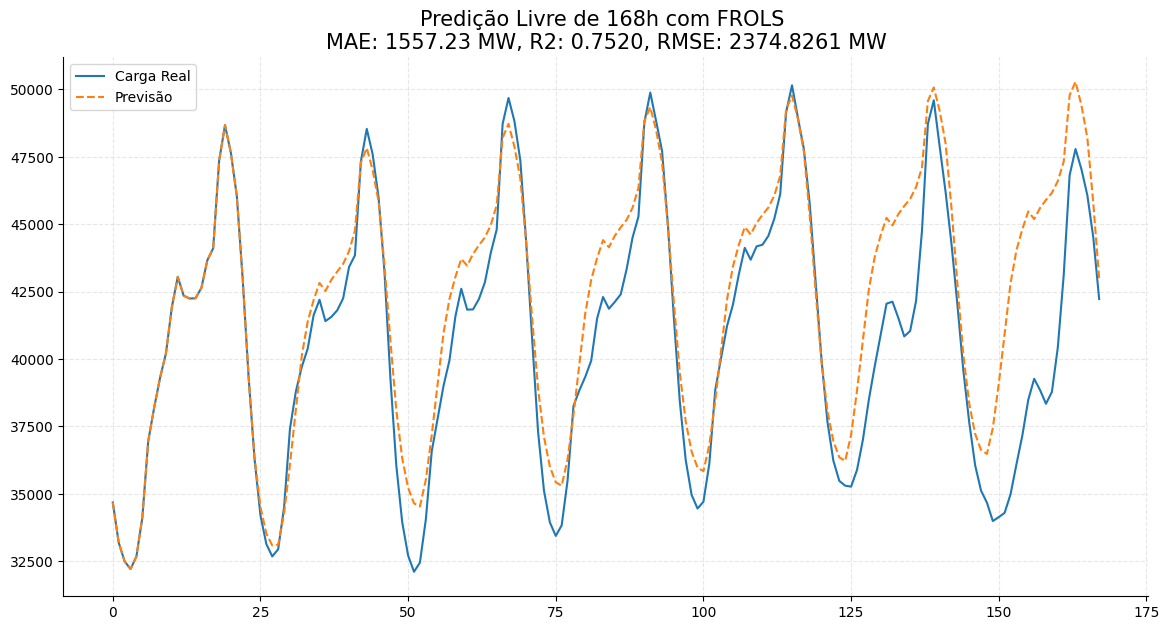

In [111]:
prediction = FROLS_predict(df, submarket, horizon, lag, seed)
plot_prediction(prediction)

### Resultados do SVM

[-0.36866621] (1,)


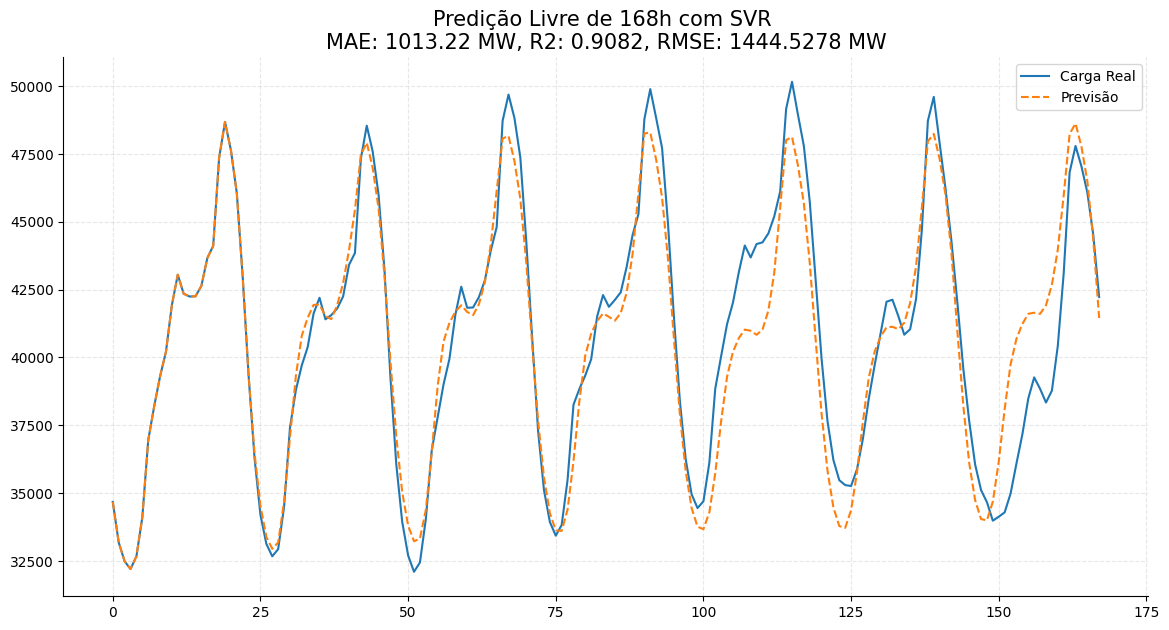

In [112]:
prediction = SVM_predict(df, submarket, horizon, lag, seed)
plot_prediction(prediction)

### Resultados do SVM com GA

Iniciando a evolução do Algoritmo Genético... Isso pode levar alguns minutos.

=== OTIMIZAÇÃO CONCLUÍDA ===
Melhor R2 encontrado na semana: 0.9366
Parâmetros do SVR: C = 3.00, gamma = 0.6690, epsilon = 0.0943
Lags Autoregressivos (ylag): [1, 2, 6, 10, 15, 19, 21, 24]
Lags Exógenos (xlag): [1, 3, 5, 6, 7, 9, 11, 12, 14, 17, 18, 19, 20]


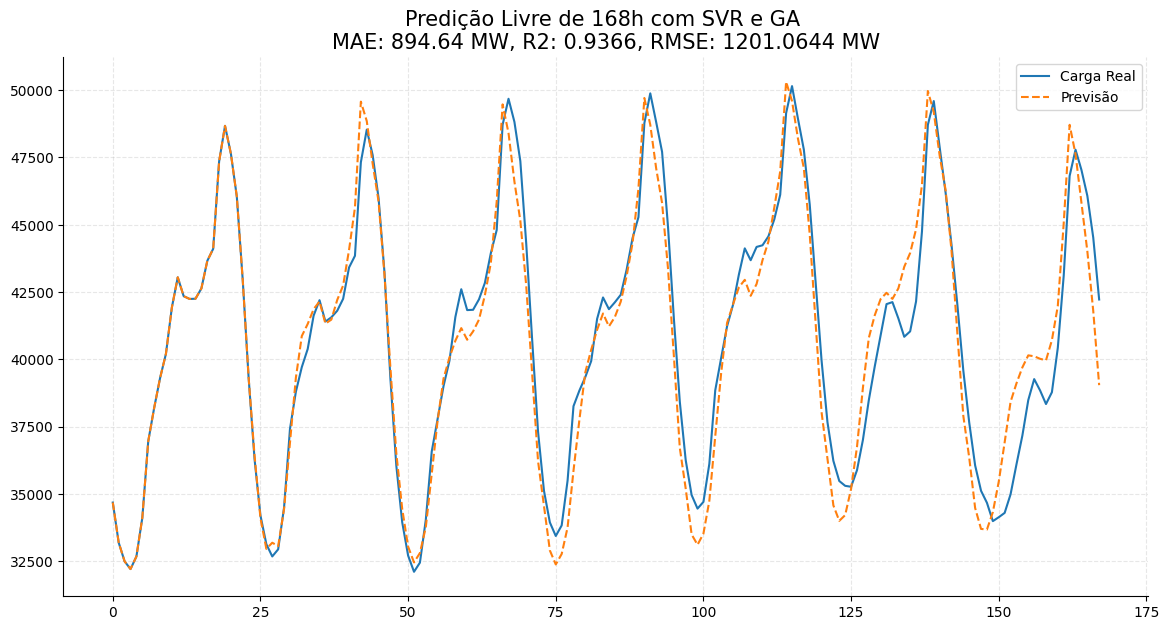

In [113]:
prediction = SVM_GA_predict(df, submarket, horizon, lag, seed)
plot_prediction(prediction)

## 10 Previsão de um mês
Para experimento, pegamos o modelo com melhor resultado e o colocamos para prever um mês de carga com lag de uma semana, sendo esse modelo o SVM com GA.

In [114]:
horizon = 730
lag = 168

### Resultados do SVM do mês

Iniciando a evolução do Algoritmo Genético... Isso pode levar alguns minutos.

=== OTIMIZAÇÃO CONCLUÍDA ===
Melhor R2 encontrado na semana: 0.9414
Parâmetros do SVR: C = 16.50, gamma = 0.0207, epsilon = 0.0705
Lags Autoregressivos (ylag): [3, 5, 8, 10, 13, 14, 16, 17, 18, 19, 20, 21, 22, 25, 26, 28, 29, 30, 31, 35, 37, 38, 39, 42, 43, 49, 51, 52, 53, 57, 60, 61, 62, 69, 71, 74, 75, 76, 78, 81, 83, 84, 85, 86, 87, 94, 95, 98, 99, 100, 106, 107, 109, 110, 111, 112, 113, 115, 116, 120, 121, 122, 123, 124, 127, 128, 129, 130, 132, 137, 138, 139, 140, 142, 145, 147, 149, 153, 154, 155, 156, 158, 161, 162, 166]
Lags Exógenos (xlag): [3, 4, 5, 6, 7, 9, 11, 12, 14, 15, 17, 23, 24, 25, 26, 27, 28, 29, 30, 32, 33, 34, 35, 37, 41, 42, 44, 48, 49, 50, 51, 53, 54, 55, 57, 58, 60, 61, 62, 63, 65, 69, 71, 76, 77, 78, 80, 81, 86, 87, 89, 91, 96, 98, 99, 105, 106, 109, 110, 111, 112, 113, 116, 117, 118, 119, 121, 122, 123, 124, 125, 126, 131, 132, 134, 146, 147, 148, 149, 150, 153, 154, 158, 159, 163, 

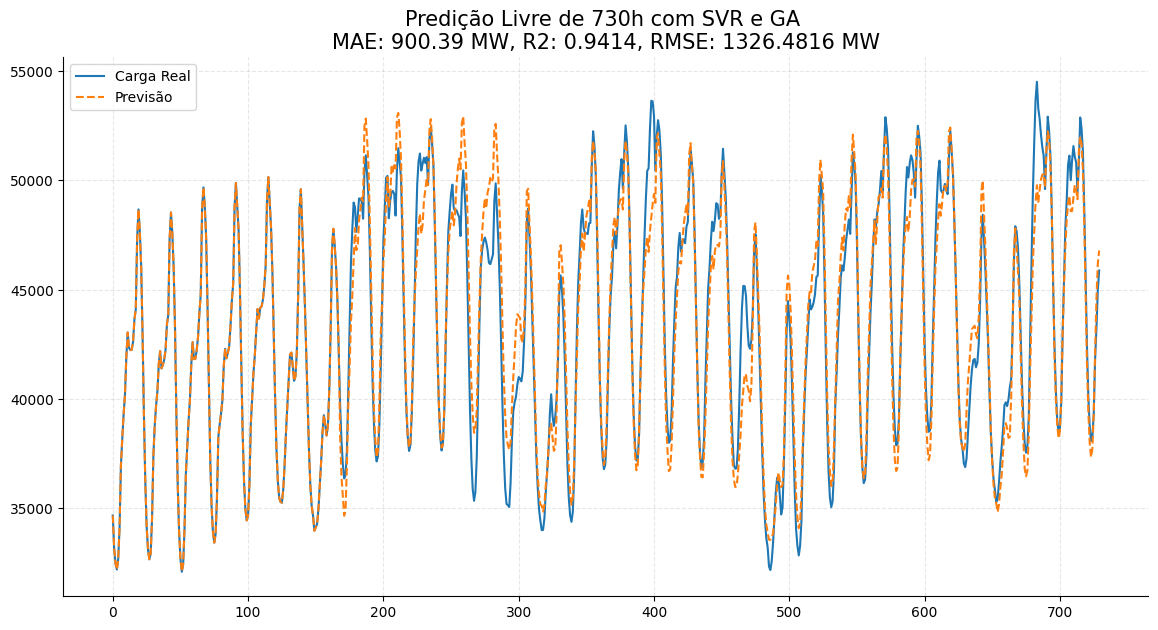

In [115]:
prediction = SVM_GA_predict(df, submarket, horizon, lag, seed)
plot_prediction(prediction)